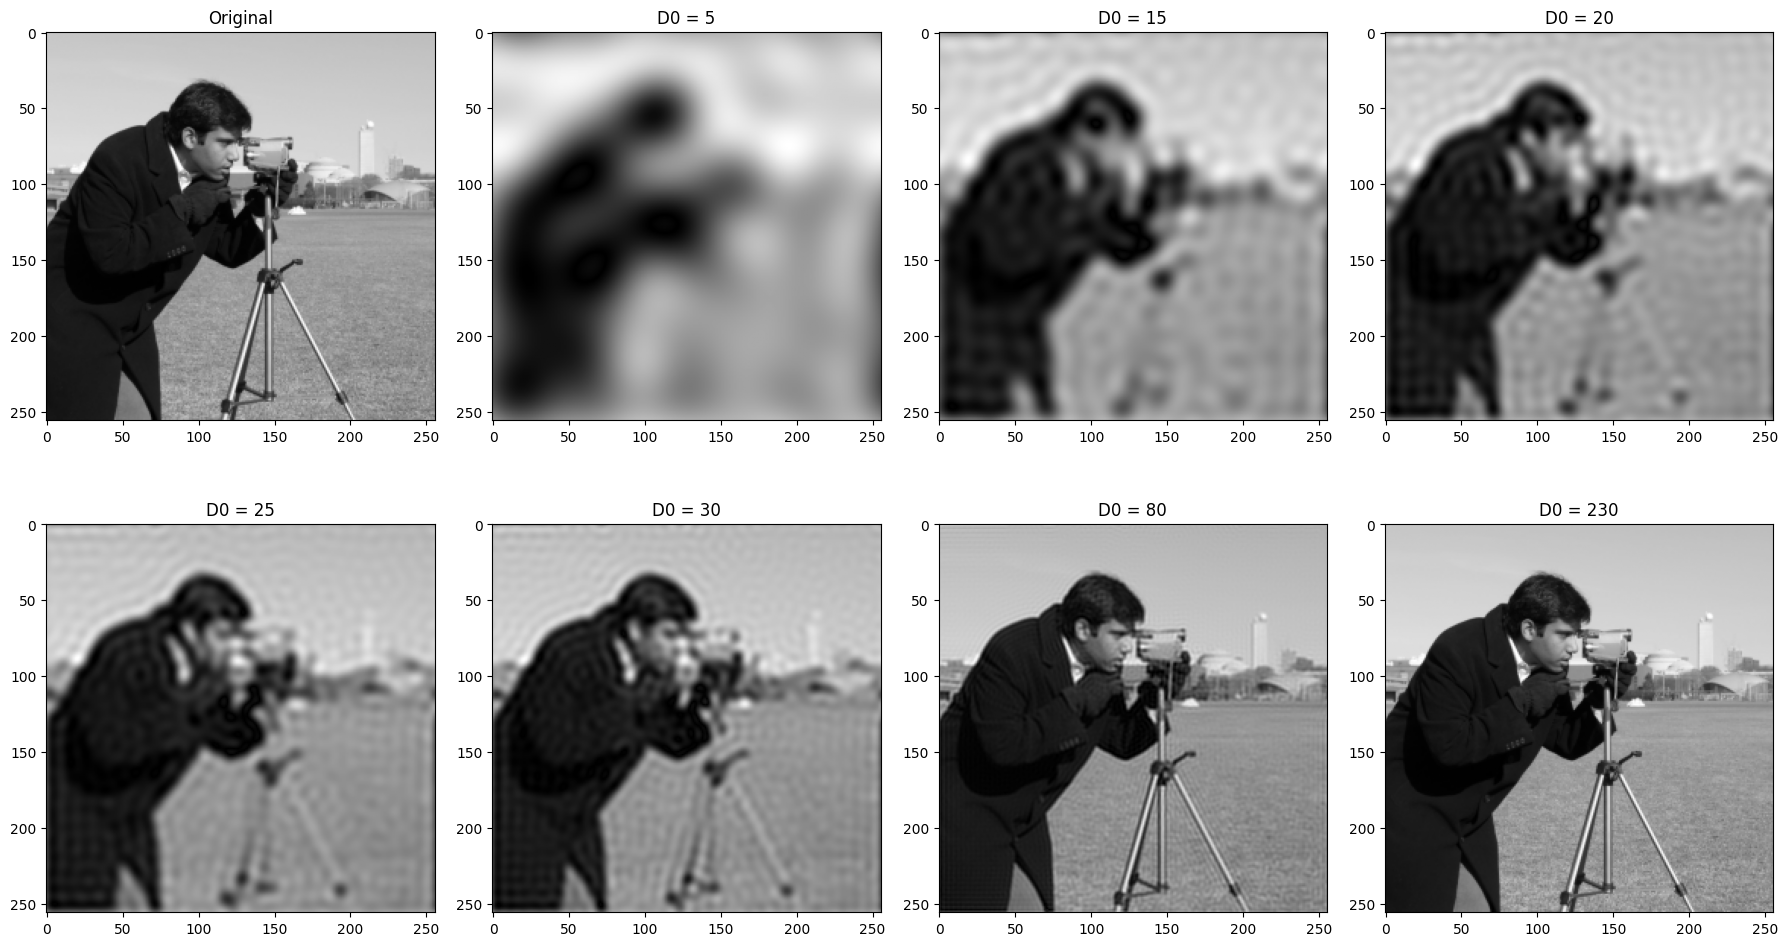

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

img = data.camera()
img = resize(img, (256, 256))
M, N = img.shape
F = np.fft.fft2(img)
F_shifted = np.fft.fftshift(F)
U, V = np.meshgrid(np.arange(N), np.arange(M))
D = np.sqrt((U - N/2)**2 + (V - M/2)**2)

cutoffs = [5, 15, 20, 25, 30, 80, 230]
results = []

for D0 in cutoffs:
    H = np.zeros((M, N))
    H[D <= D0] = 1
    G = F_shifted * H
    G_ishift = np.fft.ifftshift(G)
    img_filtered = np.fft.ifft2(G_ishift)
    img_filtered = np.abs(img_filtered)
    results.append(img_filtered)

plt.figure(figsize=(18, 10))
plt.subplot(2, 4, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
for i, D0 in enumerate(cutoffs):
    plt.subplot(2, 4, i+2)
    plt.title(f"D0 = {D0}")
    plt.imshow(results[i], cmap='gray')
plt.tight_layout()
plt.show()
